In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

df = pd.read_pickle("Data/Export 270426/data_long.pkl")

Measure MRPK and MRPL for every firm
$$
 \text{MRPK}_{ist} :=
    \left(\frac{\alpha}{\mu}\right)
    \left(\frac{p_{ist} y_{ist}}{k_{ist}}\right)
    = \left(\frac{1 + \tau^{k}_{ist}}{1 - \tau^{y}_{ist}}\right)
    (r_t + \delta_{st})
$$

$$
 \text{MRPL}_{ist} :=
    \left(\frac{1-\alpha}{\mu}\right)
    \left(\frac{p_{ist} y_{ist}}{\ell_{ist}}\right)
    = \left(\frac{1}{1 - \tau^{y}_{ist}}\right) w_{st}
$$

$$ 
TFPR_{ist} = p_{ist} A_{ist} = \frac{p_{ist} y_{ist}}{k_{ist}^\alpha l_{ist}^{1-\alpha}}
$$

In [2]:
alpha = 0.35
markup = 1

# see gopinath p. 1926

#to prevent inf values replace 0 with 1 in assets remember it is tsd
df['assets'] = df['assets'].replace(0,0.001)

#calculate firm nominal value added
df['nvad'] = df['revenue'] - df['materials']

#deflate assets and wagebill to get k and l with pricindex
df['k'] = df['assets'] / df['priceind']   #rather take investment prices ?!!
df['l'] = df['wagebill'] / df['priceind']
df['y'] = df['nvad'] / df['priceind']


#calculate mrpk
df['MRPK'] = (alpha/markup) * (df['nvad']/ df['k'])
#calculate mrpl
df['MRPL'] = ((1-alpha)/markup)* (df['nvad']/ df['l'])
#calculate firms total factor productivity
df['TFPR'] = df['revenue'] / ( (df['k']** alpha) * (df['l']**(1-alpha)) )

calculate the weights per sector $\omega_s$ is defined as:
$$
    \omega_s = \frac{1}{T}\sum_{t=1}^{T}
    \frac{\text{VA}_{st}}{\text{VA}_{t}}
$$
with $\text{VA}_{st}$ denoting value added of industry $s$
at time $t$, and $\text{VA}_{t}$ total manufacturing value
added.

In [3]:
#calculate weights per sector and year
vast = df.groupby(['sector', 'year'])['nvad'].sum().reset_index()
vat = df.groupby(['year'])['nvad'].sum().reset_index().rename(columns = {'nvad':'nvadt'})
#merge on years
vast = pd.merge(vast, vat, how='left', on='year')

#divide sectoral vad with total va per year and take mean for every sector
vast['sectorshare'] = vast['nvad'] / vast['nvadt']
weights = vast.groupby('sector')['sectorshare'].mean().reset_index().rename(columns={'sectorshare': 'sectorweight'})
print("check if weights sum to 1: ", round(weights.sectorweight.sum()))
weights

check if weights sum to 1:  1


,sector,sectorweight
0,1011,0.012406
1,1012,0.001056
2,1013,0.023224
3,1020,0.008113
4,1031,0.000877
...,...,...
225,3315,0.003710
226,3316,0.001044
227,3317,0.001023
228,3319,0.000888


For every 4 digit level sector take the standard deviation per year in MRPK
$$
 \Delta_{st} = \text{Standard Deviation}\left(\log(\{x_{ist}\}_{i=1}^{N_{st}})\right)
$$

For each year $t$,
aggregate across industries using time-invariant weights
$\omega_s$:
$$
    \Delta_t = \sum_{s} \omega_s \, \Delta_{st}
$$

In [4]:
#calcualte dispersion from log MRPK and MRPL
df['log_MRPK'] = np.log(df['MRPK'])
df['log_MRPL'] = np.log(df['MRPL'])
df['log_TFPR'] = np.log(df['TFPR'])

#group by sector, year and take std
disp = df.groupby(['sector', 'year']).agg(
                    disp_MRPK=('log_MRPK', 'std'),
                    disp_MRPL=('log_MRPL', 'std'),
                    disp_TFPR=('log_TFPR', 'std')).reset_index()

#merge weights with dispersion on sector and sum
disp = pd.merge(disp, weights, on='sector', how='left')
disp['w_disp_MRPK'] = disp['disp_MRPK'] * disp['sectorweight']
disp['w_disp_MRPL'] = disp['disp_MRPL'] * disp['sectorweight']
disp['w_disp_TFPR'] = disp['disp_TFPR'] * disp['sectorweight']
#get dispersion weighted on sectors per year
dispt = disp.groupby('year').agg({'w_disp_MRPK': 'sum', 'w_disp_MRPL': 'sum', 'w_disp_TFPR': 'sum'})
dispt

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,w_disp_MRPK,w_disp_MRPL,w_disp_TFPR
year,,,
2015,1.776814,0.568220,0.912380
2016,1.714817,0.524805,0.897773
2017,1.704768,0.534197,0.871035
2018,1.656840,0.535768,0.874160
2019,1.588651,0.536968,0.874676
2020,1.677260,0.586613,0.873186
2021,1.587993,0.516225,0.868644
2022,1.618065,0.566521,0.891345
2023,1.659005,0.537068,0.868353


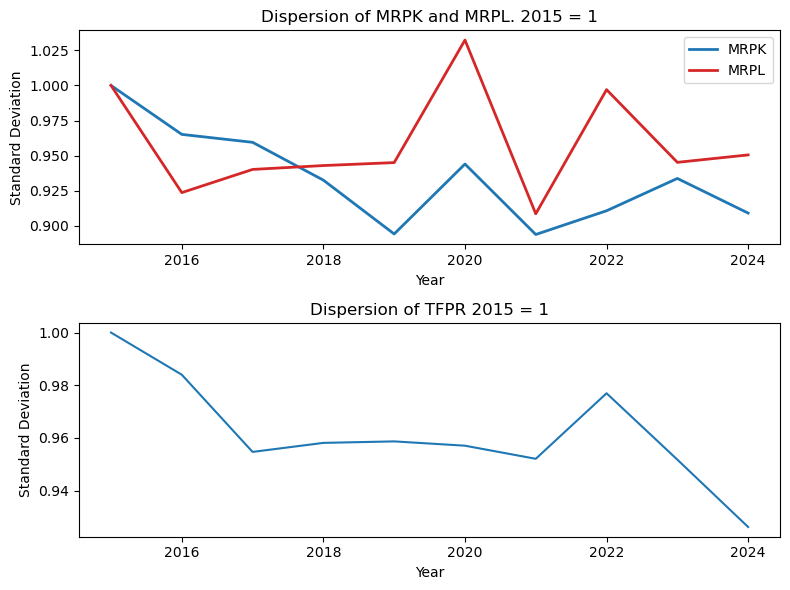

In [5]:
#normalize for start year
START_YEAR = 2015
END_YEAR = 2026

plotdf = dispt[(dispt.index >= START_YEAR) & (dispt.index <= END_YEAR)]
plotdf = plotdf / plotdf.iloc[0]
plotdf = plotdf.reset_index()


#create plot 
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8,6))

ax1.plot(plotdf["year"], plotdf["w_disp_MRPK"], label="MRPK", color="#1f77b4", linewidth=2)
ax1.plot(plotdf["year"], plotdf["w_disp_MRPL"], label="MRPL", color="#d62728", linewidth=2)
ax1.set_title(f"Dispersion of MRPK and MRPL. {plotdf['year'][0]} = 1")
ax1.set_xlabel("Year")
ax1.set_ylabel("Standard Deviation")
ax1.legend()

ax2.plot(plotdf['year'], plotdf['w_disp_TFPR'])
ax2.set_title(f"Dispersion of TFPR {plotdf['year'][0]} = 1")
ax2.set_xlabel("Year")
ax2.set_ylabel("Standard Deviation")


plt.tight_layout()
plt.show()

### Efficient level of productivity


$\varepsilon = 3$ from Hsieh and Klenov(2009) \
To find this we need to measure the firms productivity $Z_{ist}$. 

$$
\tilde{Z}_{ist} = \left(\frac{(P_{st}Y_{st})^{-\frac{1}{\varepsilon-1}}}{P_{st}}\right)\left(\frac{(p_{ist}y_{ist})^{\frac{\varepsilon}{\varepsilon-1}}}{k_{ist}^{\alpha}\ell_{ist}^{1-\alpha}}\right)
$$

$$
P_{st}Y_{st} = \sum_i{p_{ist}y_{ist}}
$$

$ P_{st} $ : Price index from eurostat ???

from Z we calculate the efficient level of productivity
$$
TFP^e_{st} = \left[ \sum_i Z^{\varepsilon-1}_{ist}    \right]^\frac{1}{\varepsilon-1}
$$

to compare it with actual TFP we construcct $TFP_{st}$ as follows:

$$ 
TFP_{st} = \frac{Y_{st}}{K^\alpha L^{1-\alpha}} = \frac{\overline{TFPR}_{st}}{P_{st}}
$$

In [6]:
#calculate firm productivity z
EPSILON = 3

#calculate sectorrevenue and merge to df
sectorrevenue = df.groupby(['year', 'sector']).agg(nvad_s = ('nvad', 'sum')).reset_index()
df = df.merge(sectorrevenue, on=['year', 'sector'], how='left')

#calculate firm productivity
df['Z'] = ((df['nvad_s']**(-(1/(EPSILON-1)))) / df['priceind'] ) * ( (df['nvad']**(EPSILON/(EPSILON-1))) / ( (df['k']**alpha) * df['l']**(1-alpha)) )
df['Z_elast'] = df['Z'] ** (EPSILON-1)
df['TFP'] = df['TFPR'] / df['priceind']
#calculate tfp per sector
tfp_st = df.groupby(['year', 'sector']).agg(
    TFPe = ('Z_elast', 'sum'),
    TFP = ('TFPR', 'sum')
).reset_index()
tfp_st['TFPe'] = tfp_st['TFPe'] ** (1/(EPSILON-1))

#add time invariant weights
tfp_st = tfp_st.merge(weights, on='sector', how='left')
tfp_st['wlTFP'] = np.log(tfp_st['TFP']) * tfp_st['sectorweight']
tfp_st['wlTFPe'] = np.log(tfp_st['TFPe']) * tfp_st['sectorweight']

tfp_t = tfp_st.groupby('year').agg({'wlTFP': 'sum', 'wlTFPe': 'sum'})
tfp_t['wlTFPg'] = tfp_t['wlTFP'].iloc[0] + np.log(1.01) * np.arange(len(tfp_t))

tfp_t

,wlTFP,wlTFPe,wlTFPg
year,,,
2015,7.398262,1.542812,7.398262
2016,7.248102,1.573911,7.408212
2017,7.282615,1.605311,7.418162
2018,7.265843,1.475134,7.428113
2019,7.186193,1.537595,7.438063
2020,7.121811,1.438672,7.448013
2021,7.198390,1.414722,7.457964
2022,7.389548,1.471962,7.467914
2023,7.434217,1.468159,7.477864


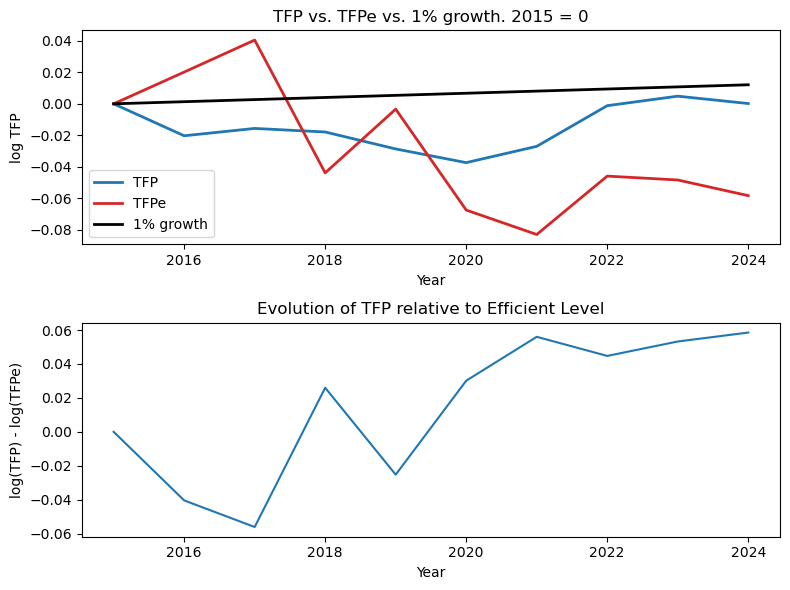

In [7]:
#create plot 
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8,6))

plotdf = tfp_t
plotdf = plotdf / plotdf.iloc[0] - 1
plotdf = plotdf.reset_index()


ax1.plot(plotdf["year"], plotdf["wlTFP"], label="TFP", color="#1f77b4", linewidth=2)
ax1.plot(plotdf["year"], plotdf["wlTFPe"], label="TFPe", color="#d62728", linewidth=2)
ax1.plot(plotdf["year"], plotdf["wlTFPg"], label="1% growth", color="black", linewidth=2)
ax1.set_title(f"TFP vs. TFPe vs. 1% growth. {plotdf['year'][0]} = 0")
ax1.set_xlabel("Year")
ax1.set_ylabel("log TFP")
ax1.legend()

ax2.plot(plotdf['year'],  plotdf["wlTFP"] -  plotdf["wlTFPe"])
ax2.set_title("Evolution of TFP relative to Efficient Level")
ax2.set_xlabel('Year')
ax2.set_ylabel('log(TFP) - log(TFPe)')

plt.tight_layout()
plt.show()

### log capital moments

In [ ]:
cap = df
cap['lk'] = np.log()

cap = df.groupby(['sector', 'year']).agg(
    stdk = ('k', 'std'),
    stdZ = ('Z', 'std')
).reset_index()

cap = cap.merge(weights, on='sector', how='left')

cap['wstdk'] = np.log(cap['stdk'] * cap['sectorweights']
cap['wstdZ'] = cap['stdZ'] * cap['sectorweights']

SyntaxError: '(' was never closed (213985814.py, line 11)